# MLP benchmark: lwtnn (float32) vs ONNX Runtime

Architecture: **60 → 128 → 64 → 32 → 16 → 8, tanh**  
Both backends use float32. lwtnn uses `generic::LightweightNeuralNetwork<float>`.

In [1]:
import json, subprocess, tempfile
from pathlib import Path

import numpy as np
import torch, torch.nn as nn
import onnx, onnxruntime as ort
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

BUILD_DIR = Path("../build")
LWTNN_F32 = BUILD_DIR / "bin" / "lwtnn-bench-mlp-f32"
ORT_BIN   = BUILD_DIR / "bin" / "ort-bench-inference"
for b in [LWTNN_F32, ORT_BIN]:
    assert b.exists(), f"not found: {b}"

MLP_LAYERS   = [60, 128, 64, 32, 16, 8]
N_INFERENCES = 2000

## Build model

In [2]:
torch.manual_seed(42)
layers = []
for i, o in zip(MLP_LAYERS[:-1], MLP_LAYERS[1:]):
    layers += [nn.Linear(i, o), nn.Tanh()]
model = nn.Sequential(*layers).eval()

ramp = torch.tensor(np.linspace(-1.0, 1.0, MLP_LAYERS[0]), dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    ref_out = model(ramp).squeeze(0).numpy()

print(f"Architecture: {' → '.join(str(s) for s in MLP_LAYERS)}, tanh")
display(pd.DataFrame([{f"out_{i}": float(v) for i, v in enumerate(ref_out)}])
        .style.format("{:.6f}").set_caption("PyTorch reference output"))

Architecture: 60 → 128 → 64 → 32 → 16 → 8, tanh


,out_0,out_1,out_2,out_3,out_4,out_5,out_6,out_7
0,0.258992,-0.067616,-0.130744,0.002533,-0.127779,0.226334,-0.126954,0.184915


## Export to lwtnn JSON and ONNX

In [3]:
tmpdir = Path(tempfile.mkdtemp())

# lwtnn JSON
json_path = tmpdir / "mlp.json"
cfg = {
    "inputs":  [{"name": f"in_{i}", "offset": 0.0, "scale": 1.0} for i in range(MLP_LAYERS[0])],
    "layers":  [{"architecture": "dense", "activation": "tanh",
                 "weights": m.weight.detach().numpy().flatten().tolist(),
                 "bias":    m.bias.detach().numpy().tolist()}
                for m in model if isinstance(m, nn.Linear)],
    "outputs": [f"out_{i}" for i in range(MLP_LAYERS[-1])],
}
json_path.write_text(json.dumps(cfg))

# ONNX
onnx_path = str(tmpdir / "mlp.onnx")
torch.onnx.export(model, ramp, onnx_path,
                  input_names=["input"], output_names=["output"],
                  opset_version=17,
                  dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}})

print(f"lwtnn JSON: {json_path}")
print(f"ONNX:       {onnx_path}  ({len(onnx.load(onnx_path).graph.node)} nodes)")

lwtnn JSON: /tmp/tmp8s64vw6f/mlp.json
ONNX:       /tmp/tmp8s64vw6f/mlp.onnx  (10 nodes)


## Output correctness

In [4]:
def run_bin(*args):
    r = subprocess.run([str(a) for a in args], capture_output=True, text=True, check=True)
    kv = {}
    for line in r.stdout.strip().splitlines():
        if "=" in line:
            k, _, v = line.partition("=")
            kv[k.strip()] = v.strip()
    return kv

# lwtnn f32 single inference
lwtnn_kv1 = run_bin(LWTNN_F32, json_path, "--n-inferences", 1)
lwtnn_out  = {k: float(v) for p in lwtnn_kv1.get("outputs", "").split()
              for k, _, v in [p.partition("=")]}

# ORT Python
sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
ort_out = sess.run(None, {"input": ramp.numpy()})[0].squeeze(0)

rows = []
for i in range(MLP_LAYERS[-1]):
    k  = f"out_{i}"
    lv = lwtnn_out.get(k, float("nan"))
    pv = float(ref_out[i])
    ov = float(ort_out[i])
    rows.append({"Output": k, "lwtnn f32": lv, "PyTorch f32": pv, "ORT f32": ov,
                 "|lwtnn − PyTorch|": abs(lv - pv), "|lwtnn − ORT|": abs(lv - ov)})

display(pd.DataFrame(rows).set_index("Output").style
    .format({"lwtnn f32": "{:.7f}", "PyTorch f32": "{:.7f}", "ORT f32": "{:.7f}",
             "|lwtnn − PyTorch|": "{:.2e}", "|lwtnn − ORT|": "{:.2e}"})
    .set_caption("Output correctness — all backends agree to < 1e-5")
    .highlight_max(subset=["|lwtnn − PyTorch|", "|lwtnn − ORT|"],
                   props="background-color:#fee2e2"))

,lwtnn f32,PyTorch f32,ORT f32,|lwtnn − PyTorch|,|lwtnn − ORT|
Output,,,,,
out_0,0.2589920,0.2589920,0.2589920,1.63e-08,4.33e-08
out_1,-0.0676160,-0.0676156,-0.0676156,3.57e-07,3.72e-07
out_2,-0.1307440,-0.1307444,-0.1307444,3.68e-07,3.53e-07
out_3,0.0025330,0.0025332,0.0025332,2.18e-07,2.18e-07
out_4,-0.1277790,-0.1277794,-0.1277793,3.65e-07,3.35e-07
out_5,0.2263340,0.2263340,0.2263340,3.54e-08,9.31e-09
out_6,-0.1269540,-0.1269535,-0.1269535,4.73e-07,4.88e-07
out_7,0.1849150,0.1849152,0.1849152,1.55e-07,1.70e-07


## C++ benchmark

In [5]:
print(f"Running {N_INFERENCES} inferences …")
lwtnn_kv = run_bin(LWTNN_F32, json_path, "--n-inferences", N_INFERENCES)
print("  lwtnn f32 done")
ort_kv   = run_bin(ORT_BIN, onnx_path, "--n-inferences", N_INFERENCES, "--n-inputs", MLP_LAYERS[0])
print("  ORT done")

KEYS = [
    ("inference_mean_us",   "Mean (µs)"),
    ("inference_min_us",    "Min (µs)"),
    ("inference_median_us", "Median (µs)"),
    ("inference_p99_us",    "p99 (µs)"),
    ("inference_max_us",    "Max (µs)"),
    ("peak_rss_kb",         "Peak RSS (MB)"),
]

rows = []
for key, label in KEYS:
    lv = float(lwtnn_kv.get(key, "nan"))
    ov = float(ort_kv.get(key,   "nan"))
    if key == "peak_rss_kb":
        lv /= 1024; ov /= 1024
    rows.append({"Metric": label, "lwtnn f32": lv, "ORT f32": ov,
                 "ORT / lwtnn": ov / lv if lv else float("nan")})

bench_df = pd.DataFrame(rows).set_index("Metric")
display(bench_df.style
    .format({"lwtnn f32": "{:.3f}", "ORT f32": "{:.3f}", "ORT / lwtnn": "{:.2f}×"})
    .set_caption(f"C++ benchmark · {N_INFERENCES} inferences · µs and MB")
    .highlight_min(axis=1, subset=["lwtnn f32", "ORT f32"], props="font-weight:bold"))

Running 2000 inferences …


  lwtnn f32 done
  ORT done


,lwtnn f32,ORT f32,ORT / lwtnn
Metric,,,
Mean (µs),6.426,5.265,0.82×
Min (µs),6.270,4.873,0.78×
Median (µs),6.385,5.041,0.79×
p99 (µs),7.243,8.571,1.18×
Max (µs),22.121,21.092,0.95×
Peak RSS (MB),13.074,33.812,2.59×


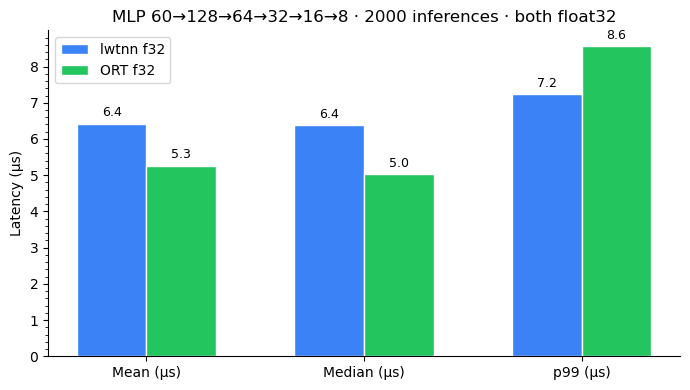

ORT mean latency is 0.82× that of lwtnn f32.
lwtnn peak RSS: 13 MB   ORT peak RSS: 34 MB  (2.6× more)


In [6]:
metrics_to_plot = ["Mean (µs)", "Median (µs)", "p99 (µs)"]
x = np.arange(len(metrics_to_plot))
w = 0.32

lwtnn_vals = [bench_df.loc[m, "lwtnn f32"] for m in metrics_to_plot]
ort_vals   = [bench_df.loc[m, "ORT f32"]   for m in metrics_to_plot]

fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - w/2, lwtnn_vals, w, label="lwtnn f32", color="#3b82f6", edgecolor="white")
b2 = ax.bar(x + w/2, ort_vals,   w, label="ORT f32",   color="#22c55e", edgecolor="white")
ax.bar_label(b1, fmt="%.1f", padding=3, fontsize=9)
ax.bar_label(b2, fmt="%.1f", padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Latency (µs)")
ax.set_title(f"MLP 60→128→64→32→16→8 · {N_INFERENCES} inferences · both float32")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
plt.tight_layout()
plt.show()

mean_ratio = bench_df.loc["Mean (µs)", "ORT / lwtnn"]
rss_lwtnn  = bench_df.loc["Peak RSS (MB)", "lwtnn f32"]
rss_ort    = bench_df.loc["Peak RSS (MB)", "ORT f32"]
print(f"ORT mean latency is {mean_ratio:.2f}× that of lwtnn f32.")
print(f"lwtnn peak RSS: {rss_lwtnn:.0f} MB   ORT peak RSS: {rss_ort:.0f} MB  "
      f"({rss_ort/rss_lwtnn:.1f}× more)")

In [7]:
import shutil
shutil.rmtree(tmpdir, ignore_errors=True)